In [1]:
# ============================================================
#  STEP 0 — Install / Import all required libraries
# ============================================================
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

# Core libraries (pre-installed on Colab, but kept for safety)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, accuracy_score,
                             precision_score, recall_score, f1_score)
from sklearn.decomposition import PCA

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [2]:
# ============================================================
# STEP 1 — Load Dataset Automatically from GitHub
# ============================================================

import pandas as pd

GITHUB_RAW_URL = "https://raw.githubusercontent.com/kashfihs/Lab4_220129_AIML/main/DT/datasets/heart_disease.csv"

df = pd.read_csv(GITHUB_RAW_URL)

print(f"✅ Dataset loaded successfully! Shape: {df.shape}")

print("\n📋 First 5 rows:")
display(df.head())

✅ Dataset loaded successfully! Shape: (303, 14)

📋 First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
# ============================================================
#  STEP 2 — Exploratory Data Analysis (EDA)
# ============================================================

print("=" * 55)
print("📊 DATASET OVERVIEW")
print("=" * 55)
print(f"Shape          : {df.shape}")
print(f"Total features : {df.shape[1] - 1}")
print(f"Target column  : target")
print(f"Classes        : {sorted(df['target'].unique().tolist())}")
print()
print("📋 Data Types:")
print(df.dtypes)
print()
print("🔍 Missing Values:")
print(df.isnull().sum())
print()
print("📈 Target Distribution:")
print(df['target'].value_counts())
print()
print("📐 Descriptive Statistics:")
df.describe()


📊 DATASET OVERVIEW
Shape          : (303, 14)
Total features : 13
Target column  : target
Classes        : [0, 1]

📋 Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

🔍 Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

📈 Target Distribution:
target
1    165
0    138
Name: count, dtype: int64

📐 Descriptive Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [4]:
# ============================================================
#  STEP 3 — Data Preprocessing
# ============================================================

df_clean = df.copy()

# ── 3a. Handle Missing Values ──────────────────────────────
print("🔧 Handling missing values...")
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype == 'object':
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
            print(f"   '{col}' (categorical) → filled with mode")
        else:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
            print(f"   '{col}' (numerical) → filled with median")

print(f"   ✅ Missing values after cleaning: {df_clean.isnull().sum().sum()}")

# ── 3b. Encode Categorical Features ───────────────────────
print("\n🔧 Encoding categorical features...")
le = LabelEncoder()
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()

if cat_cols:
    for col in cat_cols:
        df_clean[col] = le.fit_transform(df_clean[col].astype(str))
        print(f"   '{col}' → label encoded")
else:
    print("   No object-type columns found (already numeric).")

# ── 3c. Ensure target is binary int ───────────────────────
if 'target' in df_clean.columns:
    df_clean['target'] = df_clean['target'].astype(int)

# ── 3d. Feature / Label Split ─────────────────────────────
X = df_clean.drop(columns=['target'])
y = df_clean['target']
FEATURE_NAMES = X.columns.tolist()
print(f"\n✅ Features  : {X.shape[1]}")
print(f"✅ Samples   : {X.shape[0]}")
print(f"✅ Target distribution:\n{y.value_counts().to_string()}")

# ── 3e. Train / Test Split (80/20, stratified) ────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\n✅ Train size : {X_train.shape[0]}")
print(f"✅ Test size  : {X_test.shape[0]}")


🔧 Handling missing values...
   ✅ Missing values after cleaning: 0

🔧 Encoding categorical features...
   No object-type columns found (already numeric).

✅ Features  : 13
✅ Samples   : 303
✅ Target distribution:
target
1    165
0    138

✅ Train size : 242
✅ Test size  : 61


In [5]:
# ============================================================
#  STEP 4 — Hyperparameter Tuning via Cross-Validation
#           (CART — Gini  &  ID3 — Entropy)
# ============================================================

param_grid = {
    'max_depth'        : [3, 4, 5, 6, 7, 8, 10, None],
    'min_samples_split': [2, 5, 10, 15, 20]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── CART (Gini) ───────────────────────────────────────────
print("🔍 Tuning CART (Gini) ...")
cart_gs = GridSearchCV(
    DecisionTreeClassifier(criterion='gini', random_state=42),
    param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=0
)
cart_gs.fit(X_train, y_train)
best_cart = cart_gs.best_estimator_
print(f"   ✅ Best params  : {cart_gs.best_params_}")
print(f"   ✅ Best CV acc  : {cart_gs.best_score_:.4f}")

# ── ID3 (Entropy) ─────────────────────────────────────────
print("\n🔍 Tuning ID3 (Entropy) ...")
id3_gs = GridSearchCV(
    DecisionTreeClassifier(criterion='entropy', random_state=42),
    param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=0
)
id3_gs.fit(X_train, y_train)
best_id3 = id3_gs.best_estimator_
print(f"   ✅ Best params  : {id3_gs.best_params_}")
print(f"   ✅ Best CV acc  : {id3_gs.best_score_:.4f}")


🔍 Tuning CART (Gini) ...
   ✅ Best params  : {'max_depth': 3, 'min_samples_split': 2}
   ✅ Best CV acc  : 0.7770

🔍 Tuning ID3 (Entropy) ...
   ✅ Best params  : {'max_depth': 6, 'min_samples_split': 20}
   ✅ Best CV acc  : 0.7562


In [6]:
# ============================================================
#  STEP 5 — Predictions on Test Set
# ============================================================

# CART
y_pred_cart  = best_cart.predict(X_test)
y_prob_cart  = best_cart.predict_proba(X_test)[:, 1]

# ID3
y_pred_id3   = best_id3.predict(X_test)
y_prob_id3   = best_id3.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    return {
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall'   : recall_score(y_true, y_pred, zero_division=0),
        'f1'       : f1_score(y_true, y_pred, zero_division=0),
        'auc'      : roc_auc,
        'fpr'      : fpr,
        'tpr'      : tpr
    }

m_cart = get_metrics(y_test, y_pred_cart, y_prob_cart)
m_id3  = get_metrics(y_test, y_pred_id3,  y_prob_id3)

print("=" * 55)
print("📊  TEST SET EVALUATION RESULTS")
print("=" * 55)
print(f"{'Metric':<12} {'CART (Gini)':>14} {'ID3 (Entropy)':>15}")
print("-" * 45)
for k in ['accuracy','precision','recall','f1','auc']:
    print(f"{k.capitalize():<12} {m_cart[k]:>14.4f} {m_id3[k]:>15.4f}")
print("=" * 55)


📊  TEST SET EVALUATION RESULTS
Metric          CART (Gini)   ID3 (Entropy)
---------------------------------------------
Accuracy             0.7541          0.8033
Precision            0.7500          0.7838
Recall               0.8182          0.8788
F1                   0.7826          0.8286
Auc                  0.8176          0.8003


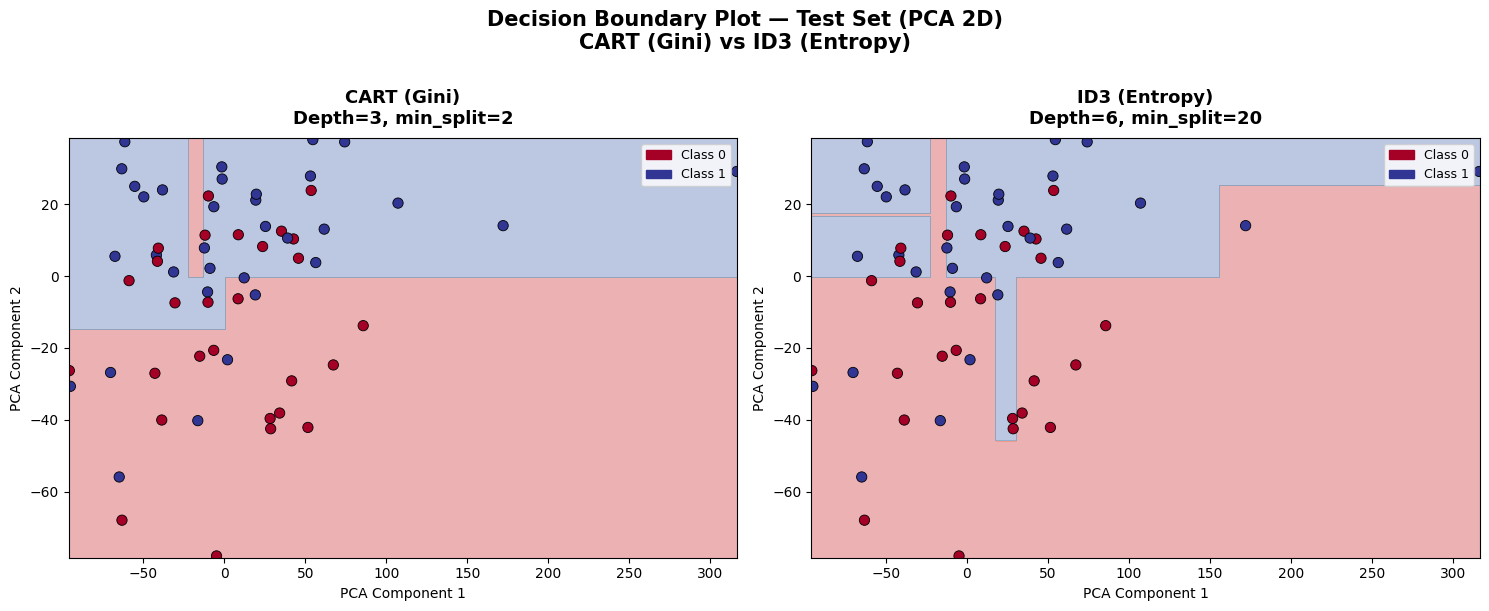

✅ Visualization 1 saved: viz1_decision_boundary.png


In [7]:
# ============================================================
#  VISUALIZATION 1 — Decision Boundary Plot (2×1)
# ============================================================

# Reduce to 2D with PCA for plotting
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train)
X_test_2d  = pca.transform(X_test)

# Refit models on 2D data for boundary
cart_2d = DecisionTreeClassifier(
    criterion='gini',
    max_depth=cart_gs.best_params_['max_depth'],
    min_samples_split=cart_gs.best_params_['min_samples_split'],
    random_state=42
).fit(X_train_2d, y_train)

id3_2d = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=id3_gs.best_params_['max_depth'],
    min_samples_split=id3_gs.best_params_['min_samples_split'],
    random_state=42
).fit(X_train_2d, y_train)

def plot_decision_boundary(ax, model, X_2d, y, title):
    h = 0.02
    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, cmap='RdYlBu')
    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y,
                         cmap='RdYlBu', edgecolors='k', s=55, linewidths=0.6)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel("PCA Component 1", fontsize=10)
    ax.set_ylabel("PCA Component 2", fontsize=10)
    class_labels = sorted(np.unique(y))
    patches = [mpatches.Patch(color=plt.cm.RdYlBu(i / (len(class_labels)-1+1e-9)),
                               label=f"Class {c}") for i, c in enumerate(class_labels)]
    ax.legend(handles=patches, loc='upper right', fontsize=9)
    return scatter

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    """Decision Boundary Plot — Test Set (PCA 2D)
CART (Gini) vs ID3 (Entropy)""",
    fontsize=15,
    fontweight='bold',
    y=1.01
)
plot_decision_boundary(axes[0], cart_2d, X_test_2d, y_test,
                       f"CART (Gini)\nDepth={cart_gs.best_params_['max_depth']}, "
                       f"min_split={cart_gs.best_params_['min_samples_split']}")
plot_decision_boundary(axes[1], id3_2d, X_test_2d, y_test,
                       f"ID3 (Entropy)\nDepth={id3_gs.best_params_['max_depth']}, "
                       f"min_split={id3_gs.best_params_['min_samples_split']}")

plt.tight_layout()
plt.savefig("viz1_decision_boundary.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualization 1 saved: viz1_decision_boundary.png")


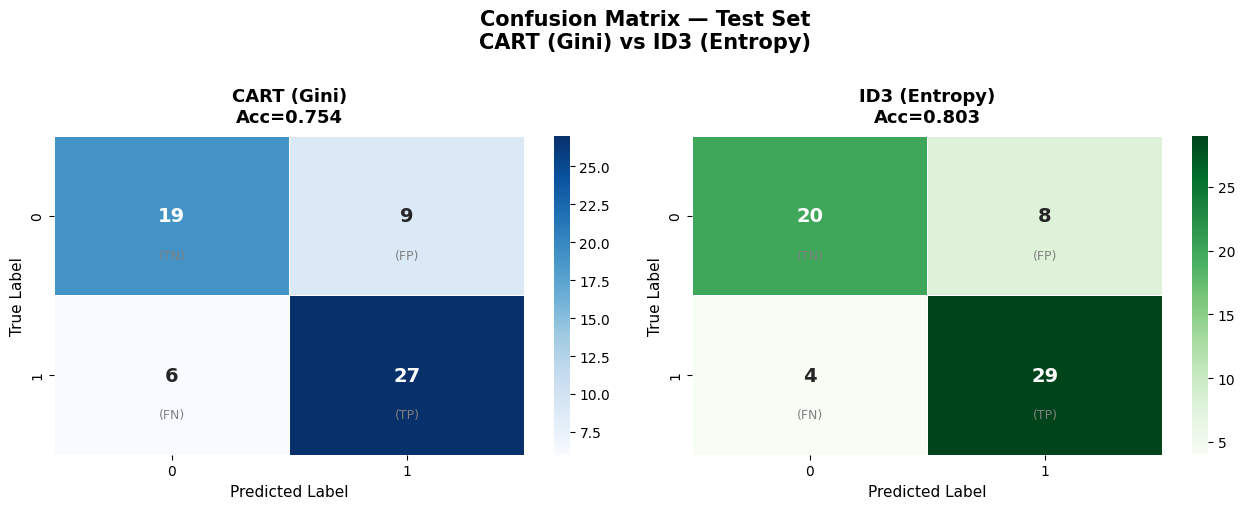

✅ Visualization 2 saved: viz2_confusion_matrix.png


In [8]:
# ============================================================
#  VISUALIZATION 2 — Confusion Matrix Heatmap (2×1)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Confusion Matrix — Test Set\nCART (Gini) vs ID3 (Entropy)",
             fontsize=15, fontweight='bold', y=1.01)

def plot_cm(ax, y_true, y_pred, title, cmap='Blues'):
    cm = confusion_matrix(y_true, y_pred)
    labels = sorted(y_true.unique())
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, linecolor='white',
                annot_kws={"size": 14, "weight": "bold"})
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)
    # Annotate TP / TN / FP / FN
    for (i, j), val in np.ndenumerate(cm):
        label = {(0,0): 'TN', (0,1): 'FP', (1,0): 'FN', (1,1): 'TP'}.get((i,j), '')
        ax.text(j + 0.5, i + 0.75, f'({label})', ha='center',
                va='center', fontsize=9, color='gray')

plot_cm(axes[0], y_test, y_pred_cart,
        f"CART (Gini)\nAcc={m_cart['accuracy']:.3f}", cmap='Blues')
plot_cm(axes[1], y_test, y_pred_id3,
        f"ID3 (Entropy)\nAcc={m_id3['accuracy']:.3f}", cmap='Greens')

plt.tight_layout()
plt.savefig("viz2_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualization 2 saved: viz2_confusion_matrix.png")


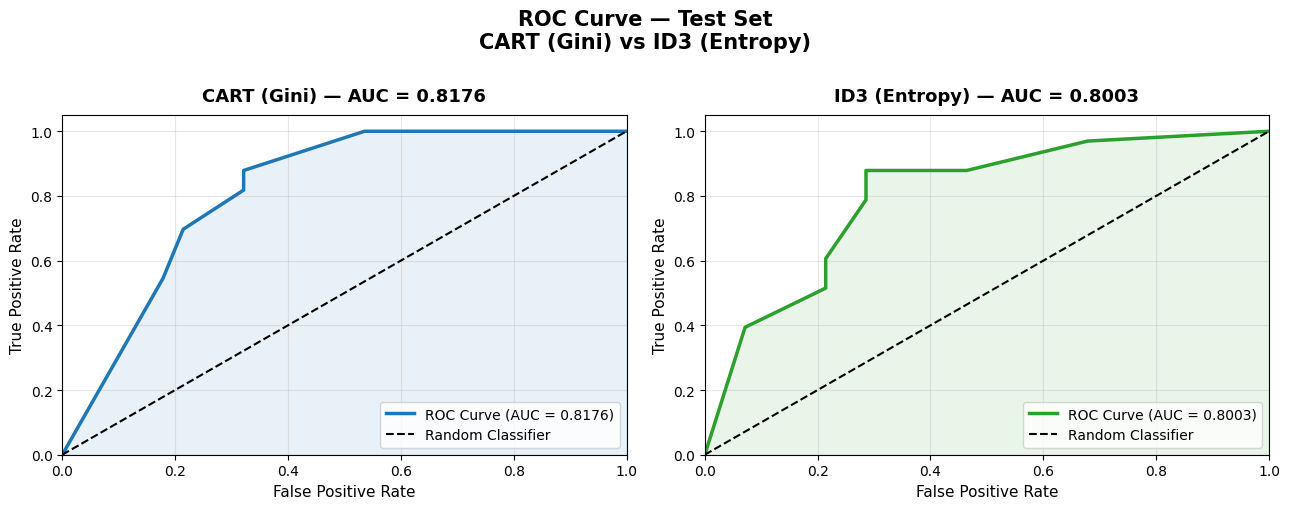

✅ Visualization 3 saved: viz3_roc_curve.png


In [9]:
# ============================================================
#  VISUALIZATION 3 — ROC Curve (2×1)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("ROC Curve — Test Set\nCART (Gini) vs ID3 (Entropy)",
             fontsize=15, fontweight='bold', y=1.01)

def plot_roc(ax, fpr, tpr, roc_auc, title, color):
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f'ROC Curve (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
    ax.fill_between(fpr, tpr, alpha=0.1, color=color)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("False Positive Rate", fontsize=11)
    ax.set_ylabel("True Positive Rate", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.legend(loc="lower right", fontsize=10)
    ax.grid(alpha=0.3)

plot_roc(axes[0], m_cart['fpr'], m_cart['tpr'], m_cart['auc'],
         f"CART (Gini) — AUC = {m_cart['auc']:.4f}", '#1f77b4')
plot_roc(axes[1], m_id3['fpr'],  m_id3['tpr'],  m_id3['auc'],
         f"ID3 (Entropy) — AUC = {m_id3['auc']:.4f}", '#2ca02c')

plt.tight_layout()
plt.savefig("viz3_roc_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualization 3 saved: viz3_roc_curve.png")


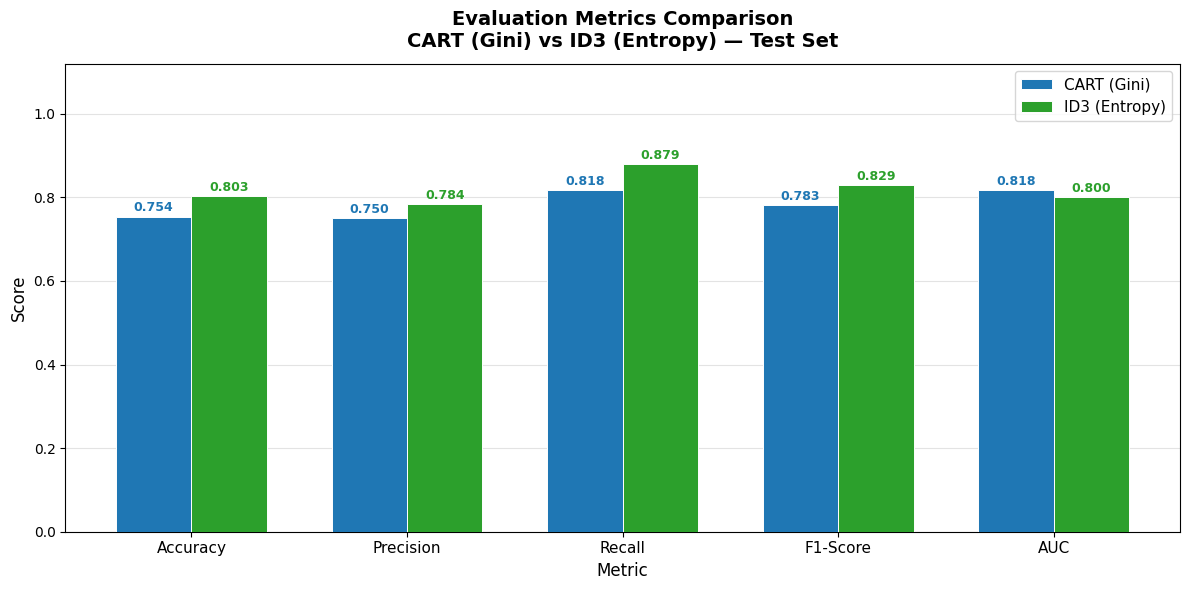

✅ Visualization 4 saved: viz4_metrics_bar.png


In [10]:
# ============================================================
#  VISUALIZATION 4 — Evaluation Metrics Bar Chart (Combined)
# ============================================================

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
cart_vals = [m_cart['accuracy'], m_cart['precision'],
             m_cart['recall'],   m_cart['f1'], m_cart['auc']]
id3_vals  = [m_id3['accuracy'],  m_id3['precision'],
             m_id3['recall'],    m_id3['f1'],  m_id3['auc']]

x    = np.arange(len(metrics_names))
w    = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - w/2, cart_vals, w, label='CART (Gini)',
               color='#1f77b4', edgecolor='white', linewidth=0.7, zorder=3)
bars2 = ax.bar(x + w/2, id3_vals,  w, label='ID3 (Entropy)',
               color='#2ca02c', edgecolor='white', linewidth=0.7, zorder=3)

# Value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#1f77b4')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#2ca02c')

ax.set_xlabel("Metric", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Evaluation Metrics Comparison\nCART (Gini) vs ID3 (Entropy) — Test Set",
             fontsize=14, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
ax.yaxis.grid(True, alpha=0.35, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("viz4_metrics_bar.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualization 4 saved: viz4_metrics_bar.png")


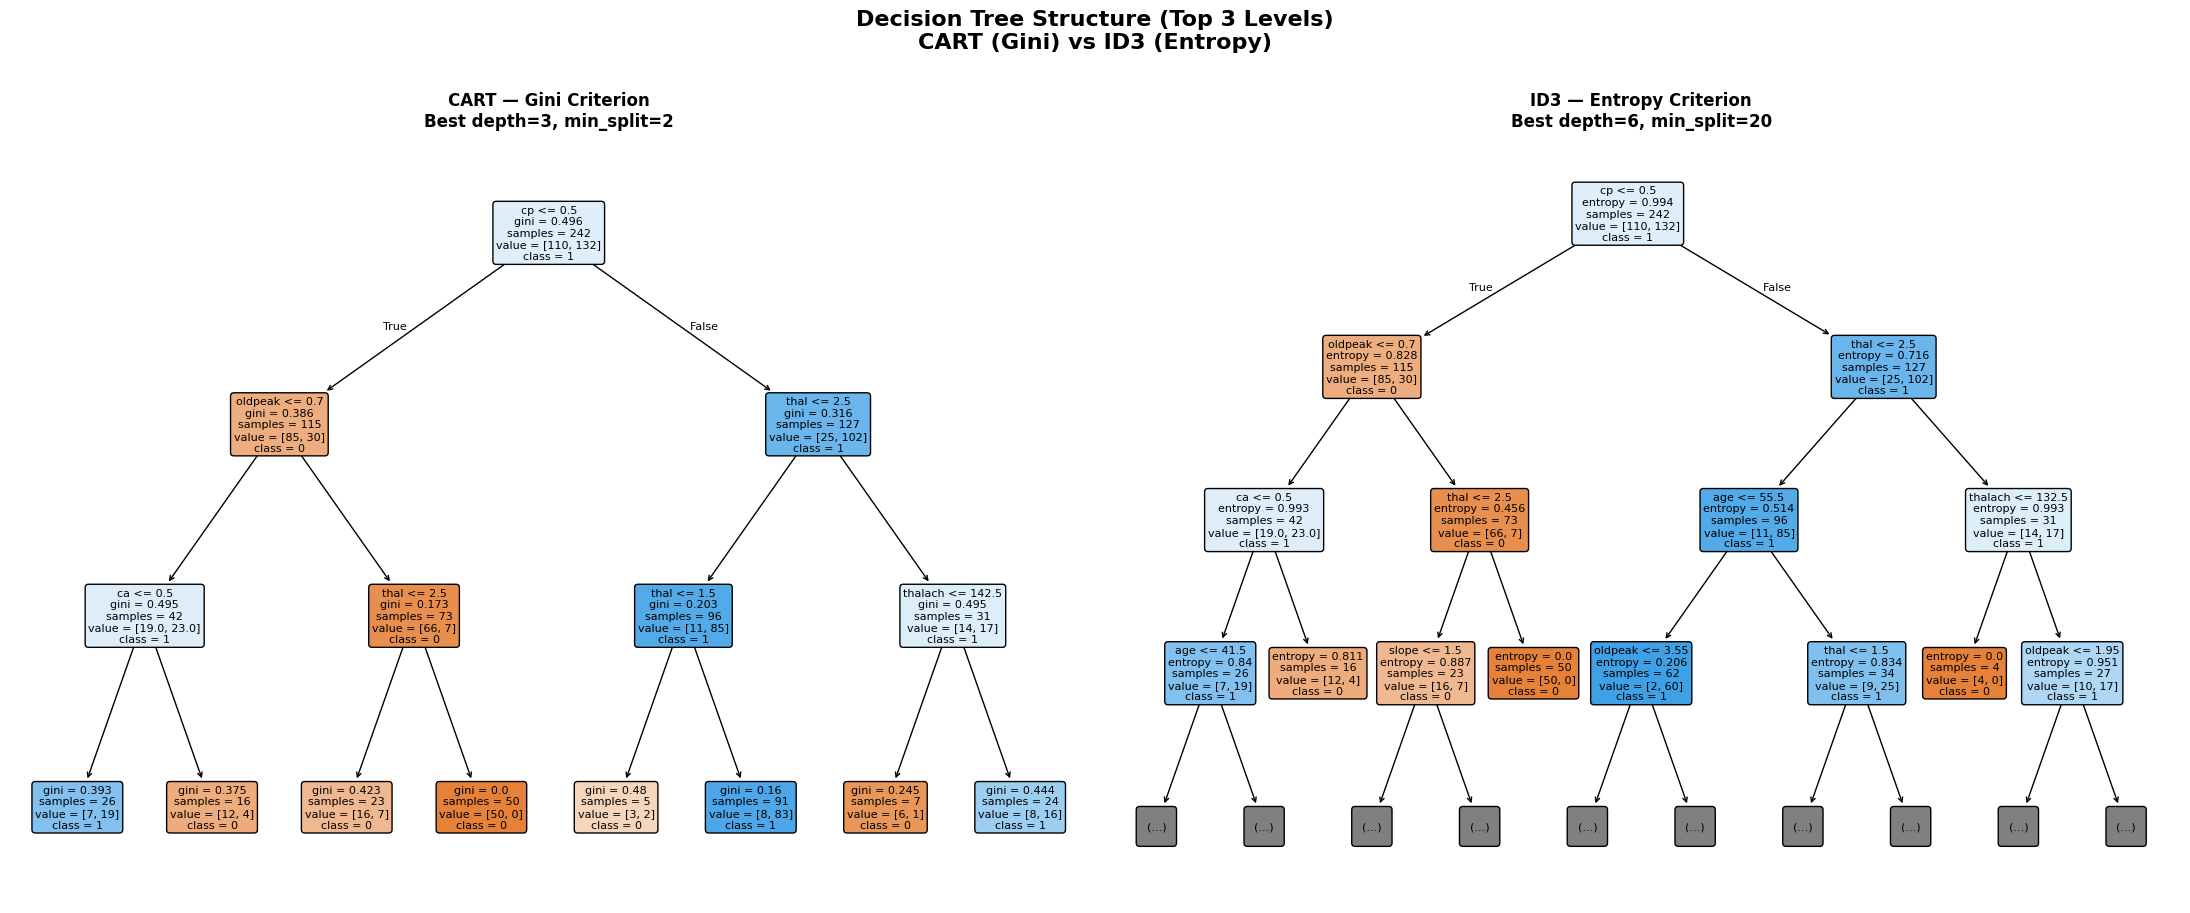

✅ Visualization 5 saved: viz5_tree_structure.png


In [11]:
# ============================================================
#  VISUALIZATION 5 — Decision Tree Structure
#  (Both trees side by side, limited depth for readability)
# ============================================================

PLOT_DEPTH = 3   # show top-3 levels for clarity

fig, axes = plt.subplots(1, 2, figsize=(22, 9), dpi=100)
fig.suptitle("Decision Tree Structure (Top 3 Levels)\nCART (Gini) vs ID3 (Entropy)",
             fontsize=16, fontweight='bold', y=1.01)

plot_tree(best_cart, ax=axes[0],
          max_depth=PLOT_DEPTH,
          feature_names=FEATURE_NAMES,
          class_names=[str(c) for c in sorted(y.unique())],
          filled=True, rounded=True, impurity=True,
          fontsize=8, precision=3)
axes[0].set_title(
    f"CART — Gini Criterion\n"
    f"Best depth={cart_gs.best_params_['max_depth']}, "
    f"min_split={cart_gs.best_params_['min_samples_split']}",
    fontsize=12, fontweight='bold', pad=8)

plot_tree(best_id3, ax=axes[1],
          max_depth=PLOT_DEPTH,
          feature_names=FEATURE_NAMES,
          class_names=[str(c) for c in sorted(y.unique())],
          filled=True, rounded=True, impurity=True,
          fontsize=8, precision=3)
axes[1].set_title(
    f"ID3 — Entropy Criterion\n"
    f"Best depth={id3_gs.best_params_['max_depth']}, "
    f"min_split={id3_gs.best_params_['min_samples_split']}",
    fontsize=12, fontweight='bold', pad=8)

plt.tight_layout()
plt.savefig("viz5_tree_structure.png", dpi=120, bbox_inches='tight')
plt.show()
print("✅ Visualization 5 saved: viz5_tree_structure.png")


In [12]:
# ============================================================
#  STEP 6 — Final Summary Report
# ============================================================

print("=" * 60)
print("        📋  FINAL SUMMARY REPORT")
print("=" * 60)
print(f"  Dataset shape          : {df.shape}")
print(f"  Train / Test split     : {X_train.shape[0]} / {X_test.shape[0]}")
print()
print(f"  {'Hyperparameter':<30} {'CART':>10} {'ID3':>10}")
print(f"  {'-'*52}")
print(f"  {'Best max_depth':<30} "
      f"{str(cart_gs.best_params_['max_depth']):>10} "
      f"{str(id3_gs.best_params_['max_depth']):>10}")
print(f"  {'Best min_samples_split':<30} "
      f"{cart_gs.best_params_['min_samples_split']:>10} "
      f"{id3_gs.best_params_['min_samples_split']:>10}")
print(f"  {'CV Accuracy':<30} "
      f"{cart_gs.best_score_:>10.4f} "
      f"{id3_gs.best_score_:>10.4f}")
print()
print(f"  {'Test Metric':<30} {'CART':>10} {'ID3':>10}")
print(f"  {'-'*52}")
for k, label in [('accuracy','Accuracy'),('precision','Precision'),
                  ('recall','Recall'),('f1','F1-Score'),('auc','AUC')]:
    print(f"  {label:<30} {m_cart[k]:>10.4f} {m_id3[k]:>10.4f}")

winner = "CART (Gini)" if m_cart['f1'] >= m_id3['f1'] else "ID3 (Entropy)"
print()
print(f"  🏆 Better F1-Score     : {winner}")
print()
print("  📁 Saved files:")
for f in ['viz1_decision_boundary.png','viz2_confusion_matrix.png',
          'viz3_roc_curve.png','viz4_metrics_bar.png','viz5_tree_structure.png']:
    print(f"     ✅  {f}")
print("=" * 60)
print("  🎉  All steps completed successfully!")
print("=" * 60)


        📋  FINAL SUMMARY REPORT
  Dataset shape          : (303, 14)
  Train / Test split     : 242 / 61

  Hyperparameter                       CART        ID3
  ----------------------------------------------------
  Best max_depth                          3          6
  Best min_samples_split                  2         20
  CV Accuracy                        0.7770     0.7562

  Test Metric                          CART        ID3
  ----------------------------------------------------
  Accuracy                           0.7541     0.8033
  Precision                          0.7500     0.7838
  Recall                             0.8182     0.8788
  F1-Score                           0.7826     0.8286
  AUC                                0.8176     0.8003

  🏆 Better F1-Score     : ID3 (Entropy)

  📁 Saved files:
     ✅  viz1_decision_boundary.png
     ✅  viz2_confusion_matrix.png
     ✅  viz3_roc_curve.png
     ✅  viz4_metrics_bar.png
     ✅  viz5_tree_structure.png
  🎉  All steps co